# Pipeline 2 — Reintegration Drivers (Explanatory)

## 1) Problem Framing

**Business question:** Which factors most strongly *explain* reintegration completion (not only predict it), and in what direction?

- **Type:** Explanatory / inference-oriented (interpretable coefficients).
- **Target:** `reintegration_complete` — same definition as Pipeline 1 (`reintegration_status == 'Completed'`).
- **Primary metrics:** Adjusted R² (OLS), coefficient significance (p-values), pseudo-R² (logistic comparison).
- **Operational use:** Publish **one org-level insight** row to `ml_predictions` with top drivers for impact/donor messaging.

### Prediction vs explanation (textbook framing)

Pipeline 1 prioritizes **predictive accuracy** (ROC-AUC, held-out discrimination). Pipeline 2 prioritizes **interpretable associations** (linear coefficients on a defensible feature set, multicollinearity control). The same resident-month features can support both goals, but feature selection and evaluation criteria differ: here we avoid RFECV-for-prediction as the final selector and emphasize VIF and domain reasoning.


> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.

In [1]:
# 2) Data Acquisition and Preparation — import shared features
import json
import sys
import os
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from dotenv import load_dotenv
from sqlalchemy import create_engine

RANDOM_STATE = 42

# ── Database connection ─────────────────────────────────────────────────────
env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in ['.env', 'ml/.env']:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

# ── Table names ─────────────────────────────────────────────────────────────
TABLE_RESIDENTS          = "residents"
TABLE_HEALTH             = "health_wellbeing_records"
TABLE_EDUCATION          = "education_records"
TABLE_PROCESS_RECORDINGS = "process_recordings"
TABLE_HOME_VISITATIONS   = "home_visitations"
TABLE_INTERVENTION_PLANS = "intervention_plans"

# ── Model paths ─────────────────────────────────────────────────────────────
MODEL_DIR = Path.cwd().parent / "models" / "reintegration-drivers"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "model.sav"
RUNS_PATH  = MODEL_DIR / "model.json"
MODEL_NAME = "reintegration-drivers"


def fetch_table(table_name):
    """Fetch an entire table into a DataFrame."""
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df


# ── Feature engineering constants ───────────────────────────────────────────
RISK_MAP = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
POSITIVE_EMOTIONS = {"Happy", "Hopeful", "Calm"}
COOPERATIVE_LEVELS = {"Cooperative", "Highly Cooperative"}
TRAUMA_WEIGHTS = {
    "sub_cat_sexual_abuse": 3.0,
    "sub_cat_trafficked": 3.0,
    "sub_cat_osaec": 3.0,
    "sub_cat_physical_abuse": 2.0,
    "sub_cat_child_labor": 2.0,
    "sub_cat_at_risk": 1.0,
}


def _to_bool_series(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    normalized = series.fillna(False)
    if normalized.dtype == object:
        normalized = normalized.astype(str).str.strip().str.lower().map(
            {"true": True, "1": True, "yes": True, "false": False, "0": False, "no": False}
        )
    return normalized.fillna(False).astype(bool)


def _safe_datetime(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True)


def _positive_denominator(series: pd.Series) -> pd.Series:
    return series.replace(0, np.nan)


def engineer_resident_base_features(residents, now_utc=None):
    if now_utc is None:
        now_utc = datetime.now(timezone.utc)
    df = residents.copy()
    df["date_of_birth"] = _safe_datetime(df.get("date_of_birth"))
    df["date_of_admission"] = _safe_datetime(df.get("date_of_admission"))
    df["date_closed"] = _safe_datetime(df.get("date_closed"))
    close_dates = df["date_closed"].fillna(pd.Timestamp(now_utc))
    admission = df["date_of_admission"]
    df["age_at_admission"] = ((admission - df["date_of_birth"]).dt.days / 365.25).clip(lower=0)
    df["length_of_stay_days"] = (close_dates - admission).dt.days.clip(lower=0)
    df["length_of_stay_months"] = (df["length_of_stay_days"] / 30.44).clip(lower=1 / 30.44)
    df["initial_risk_num"] = df.get("initial_risk_level").map(RISK_MAP).fillna(0)
    df["current_risk_num"] = df.get("current_risk_level").map(RISK_MAP).fillna(0)
    df["risk_reduction"] = df["initial_risk_num"] - df["current_risk_num"]
    trauma_score = pd.Series(0.0, index=df.index)
    for col, weight in TRAUMA_WEIGHTS.items():
        if col in df.columns:
            trauma_score += _to_bool_series(df[col]).astype(float) * weight
    df["trauma_severity_score"] = trauma_score
    family_cols = [c for c in df.columns if c.startswith("family_")]
    if family_cols:
        family_bool = pd.concat([_to_bool_series(df[c]) for c in family_cols], axis=1)
        df["family_vulnerability_score"] = family_bool.sum(axis=1)
    else:
        df["family_vulnerability_score"] = 0
    keep_cols = [
        "resident_id", "case_category", "age_at_admission",
        "length_of_stay_days", "length_of_stay_months",
        "initial_risk_num", "current_risk_num", "risk_reduction",
        "trauma_severity_score", "family_vulnerability_score",
    ]
    return df[keep_cols].copy()


def engineer_health_features(health):
    if health.empty:
        return pd.DataFrame(columns=["resident_id", "avg_health", "health_trend", "checkup_compliance", "psych_checkups", "medical_checkups"])
    df = health.copy()
    df["recorded_at"] = _safe_datetime(df.get("recorded_at"))
    df["general_health_score"] = pd.to_numeric(df.get("general_health_score"), errors="coerce")
    grouped = df.sort_values(["resident_id", "recorded_at"]).groupby("resident_id", as_index=False)
    out = grouped.agg(
        avg_health=("general_health_score", "mean"),
        first_health=("general_health_score", "first"),
        last_health=("general_health_score", "last"),
        psych_checkups=("psychological_checkup_done", lambda s: _to_bool_series(s).sum()),
        medical_checkups=("medical_checkup_done", lambda s: _to_bool_series(s).sum()),
        checkup_compliance=("psychological_checkup_done", lambda s: _to_bool_series(s).mean()),
    )
    out["health_trend"] = out["last_health"] - out["first_health"]
    return out.drop(columns=["first_health", "last_health"])


def engineer_education_features(education):
    if education.empty:
        return pd.DataFrame(columns=["resident_id", "avg_progress", "avg_attendance", "courses_completed"])
    df = education.copy()
    df["progress_percent"] = pd.to_numeric(df.get("progress_percent"), errors="coerce")
    df["attendance_rate"] = pd.to_numeric(df.get("attendance_rate"), errors="coerce")
    status = df.get("completion_status", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_completed"] = status.eq("Completed")
    out = df.groupby("resident_id", as_index=False).agg(
        avg_progress=("progress_percent", "mean"),
        avg_attendance=("attendance_rate", "mean"),
        courses_completed=("is_completed", "sum"),
    )
    return out


def engineer_process_features(process_recordings):
    if process_recordings.empty:
        return pd.DataFrame(columns=["resident_id", "total_sessions", "positive_session_rate", "pct_concerns", "avg_duration"])
    df = process_recordings.copy()
    end_state = df.get("emotional_state_end", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_positive"] = end_state.isin(POSITIVE_EMOTIONS)
    df["concerns_flagged"] = _to_bool_series(df.get("concerns_flagged", pd.Series(False, index=df.index)))
    df["session_duration_minutes"] = pd.to_numeric(df.get("session_duration_minutes"), errors="coerce")
    out = df.groupby("resident_id", as_index=False).agg(
        total_sessions=("resident_id", "size"),
        positive_session_rate=("is_positive", "mean"),
        pct_concerns=("concerns_flagged", "mean"),
        avg_duration=("session_duration_minutes", "mean"),
    )
    return out


def engineer_home_visit_features(home_visitations):
    if home_visitations.empty:
        return pd.DataFrame(columns=["resident_id", "total_visits", "favorable_rate", "family_coop_rate", "safety_concern_rate", "post_placement_visits", "reintegration_assessments"])
    df = home_visitations.copy()
    outcome = df.get("visit_outcome", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    coop = df.get("family_cooperation_level", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    visit_type = df.get("visit_type", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_favorable"] = outcome.eq("Favorable")
    df["is_cooperative"] = coop.isin(COOPERATIVE_LEVELS)
    df["safety_concerns_noted"] = _to_bool_series(df.get("safety_concerns_noted", pd.Series(False, index=df.index)))
    df["is_post_placement"] = visit_type.eq("Post-Placement Monitoring")
    df["is_reintegration_assessment"] = visit_type.eq("Reintegration Assessment")
    out = df.groupby("resident_id", as_index=False).agg(
        total_visits=("resident_id", "size"),
        favorable_rate=("is_favorable", "mean"),
        family_coop_rate=("is_cooperative", "mean"),
        safety_concern_rate=("safety_concerns_noted", "mean"),
        post_placement_visits=("is_post_placement", "sum"),
        reintegration_assessments=("is_reintegration_assessment", "sum"),
    )
    return out


def engineer_intervention_features(intervention_plans):
    empty_cols = ["resident_id", "intervention_plan_count", "intervention_achieved_rate"]
    if intervention_plans.empty:
        return pd.DataFrame(columns=empty_cols)
    df = intervention_plans.copy()
    if "resident_id" not in df.columns:
        return pd.DataFrame(columns=empty_cols)
    status = df.get("status", pd.Series(index=df.index, dtype=object)).fillna("").astype(str).str.strip()
    st_lower = status.str.lower()
    df["is_achieved"] = st_lower.isin({"achieved", "completed", "complete"}) | st_lower.str.contains("achiev", na=False)
    out = df.groupby("resident_id", as_index=False).agg(
        intervention_plan_count=("resident_id", "size"),
        intervention_achieved_rate=("is_achieved", "mean"),
    )
    return out


def build_reintegration_feature_frame(residents, health, education, process_recordings, home_visitations, intervention_plans=None):
    if intervention_plans is None:
        intervention_plans = pd.DataFrame()
    base = engineer_resident_base_features(residents)
    health_f = engineer_health_features(health)
    edu_f = engineer_education_features(education)
    proc_f = engineer_process_features(process_recordings)
    visit_f = engineer_home_visit_features(home_visitations)
    int_f = engineer_intervention_features(intervention_plans)
    feature_df = base.merge(health_f, on="resident_id", how="left")
    feature_df = feature_df.merge(edu_f, on="resident_id", how="left")
    feature_df = feature_df.merge(proc_f, on="resident_id", how="left")
    feature_df = feature_df.merge(visit_f, on="resident_id", how="left")
    feature_df = feature_df.merge(int_f, on="resident_id", how="left")
    months = _positive_denominator(feature_df["length_of_stay_months"])
    feature_df["sessions_per_month"] = feature_df.get("total_sessions", 0) / months
    feature_df["visits_per_month"] = feature_df.get("total_visits", 0) / months
    case_dummies = pd.get_dummies(feature_df["case_category"], prefix="case_category", dtype=float)
    feature_df = pd.concat([feature_df.drop(columns=["case_category"]), case_dummies], axis=1)
    feature_df.columns = pd.Index([str(c) for c in feature_df.columns])
    feature_df = feature_df.fillna(0)
    return feature_df


def build_target(residents):
    status = residents.get("reintegration_status", pd.Series(index=residents.index, dtype=object))
    return status.fillna("").astype(str).eq("Completed").astype(int)


def build_training_frame():
    """Load tables, engineer features, return one-row-per-resident training frame."""
    residents = fetch_table(TABLE_RESIDENTS)
    residents = residents[residents["reintegration_status"].notna()].copy()
    y = build_target(residents).rename("reintegration_complete")
    X = build_reintegration_feature_frame(
        residents=residents,
        health=fetch_table(TABLE_HEALTH),
        education=fetch_table(TABLE_EDUCATION),
        process_recordings=fetch_table(TABLE_PROCESS_RECORDINGS),
        home_visitations=fetch_table(TABLE_HOME_VISITATIONS),
        intervention_plans=fetch_table(TABLE_INTERVENTION_PLANS),
    )
    train_df = X.merge(
        residents[["resident_id"]].assign(reintegration_complete=y.values),
        on="resident_id", how="inner",
    )
    return train_df

In [2]:
train_df = build_training_frame()

assert "reintegration_complete" in train_df.columns
assert train_df["resident_id"].is_unique

y = train_df["reintegration_complete"].astype(int)
X = train_df.drop(columns=["reintegration_complete", "resident_id"], errors="ignore")

print("Rows:", len(train_df))
print("Feature count:", X.shape[1])
print("Class distribution:\n", y.value_counts())


Rows: 60
Feature count: 34
Class distribution:
 reintegration_complete
0    41
1    19
Name: count, dtype: int64


In [3]:
# --- Missing value and outlier check ---
print('=== Missing Values ===')
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values in the feature matrix.')
else:
    print(missing[missing > 0])

print()
print('=== Dataset Shape ===')
print(f'Rows: {len(X)}, Features: {X.shape[1]}')

print()
print('=== Outlier Check (numeric features) ===')
outlier_found = False
for col in X.select_dtypes(include=[np.number]).columns:
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} IQR outliers ({outliers/len(X)*100:.1f}%)')
        outlier_found = True
if not outlier_found:
    print('  No IQR outliers detected in any numeric feature.')

print()
print('=== Feature Summary ===')
display(X.describe(include="all").T)


=== Missing Values ===
No missing values in the feature matrix.

=== Dataset Shape ===
Rows: 60, Features: 34

=== Outlier Check (numeric features) ===
  current_risk_num: 1 IQR outliers (1.7%)
  risk_reduction: 2 IQR outliers (3.3%)
  trauma_severity_score: 2 IQR outliers (3.3%)
  family_vulnerability_score: 29 IQR outliers (48.3%)
  avg_health: 2 IQR outliers (3.3%)
  psych_checkups: 1 IQR outliers (1.7%)
  medical_checkups: 1 IQR outliers (1.7%)
  avg_progress: 2 IQR outliers (3.3%)
  avg_attendance: 6 IQR outliers (10.0%)
  total_sessions: 3 IQR outliers (5.0%)
  positive_session_rate: 2 IQR outliers (3.3%)
  pct_concerns: 1 IQR outliers (1.7%)
  avg_duration: 2 IQR outliers (3.3%)
  total_visits: 2 IQR outliers (3.3%)
  favorable_rate: 4 IQR outliers (6.7%)
  family_coop_rate: 6 IQR outliers (10.0%)
  post_placement_visits: 3 IQR outliers (5.0%)
  reintegration_assessments: 3 IQR outliers (5.0%)
  intervention_achieved_rate: 1 IQR outliers (1.7%)
  case_category_Foundling: 11 IQR 

,count,mean,std,min,25%,50%,75%,max
age_at_admission,60.0,13.903445,2.788593,8.763860,12.019165,14.892539,15.183436,17.700205
length_of_stay_days,60.0,592.533333,253.909130,191.000000,399.500000,565.000000,728.000000,1186.000000
length_of_stay_months,60.0,19.465615,8.341299,6.274639,13.124179,18.561104,23.915900,38.961892
initial_risk_num,60.0,2.216667,0.903696,1.000000,2.000000,2.000000,3.000000,4.000000
current_risk_num,60.0,1.550000,0.723105,1.000000,1.000000,1.000000,2.000000,4.000000
risk_reduction,60.0,0.666667,0.836998,0.000000,0.000000,0.000000,1.000000,3.000000
trauma_severity_score,60.0,2.500000,2.281094,0.000000,0.000000,3.000000,3.250000,9.000000
family_vulnerability_score,60.0,1.083333,0.907439,0.000000,0.750000,1.000000,1.000000,4.000000
avg_health,60.0,17.315357,1.450150,14.177778,16.238889,17.076263,18.101875,21.242857
psych_checkups,60.0,4.250000,1.733274,2.000000,3.000000,4.000000,5.000000,9.000000


## 3) Exploration (Ch. 6-8)

This notebook must be self-contained. Below we show key distributions, correlations, and relationships in the data — not deferring to Pipeline 1.

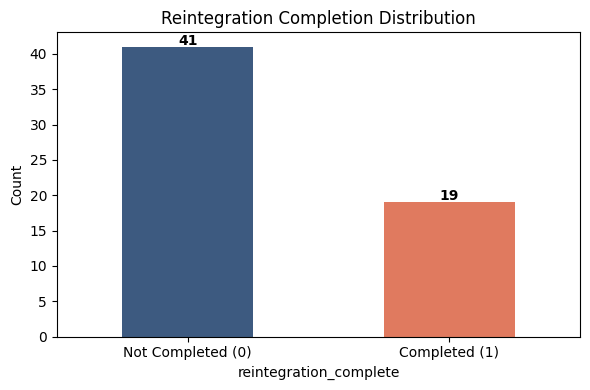

Completion rate: 31.7% (19 of 60 residents)

Top correlations with reintegration_complete:
reintegration_complete       1.000000
visits_per_month             0.415323
total_visits                 0.321012
trauma_severity_score        0.293028
case_category_Surrendered    0.251643
post_placement_visits        0.215622
sessions_per_month           0.212784
age_at_admission             0.169407
avg_health                   0.157792
medical_checkups             0.157580
favorable_rate               0.149727
total_sessions               0.137577
checkup_compliance           0.117901
positive_session_rate        0.107166
psych_checkups               0.088594
Name: reintegration_complete, dtype: float64


In [4]:
# 3a) Target distribution
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().plot(kind="bar", color=["#3d5a80", "#e07a5f"], ax=ax)
ax.set_xticklabels(["Not Completed (0)", "Completed (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Reintegration Completion Distribution")
for i, v in enumerate(y.value_counts().values):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Completion rate: {y.mean():.1%} ({y.sum()} of {len(y)} residents)")

# 3b) Correlation with target
corr = train_df.drop(columns=["resident_id"], errors="ignore").corr(numeric_only=True)
print("\nTop correlations with reintegration_complete:")
print(corr["reintegration_complete"].sort_values(ascending=False).head(15))

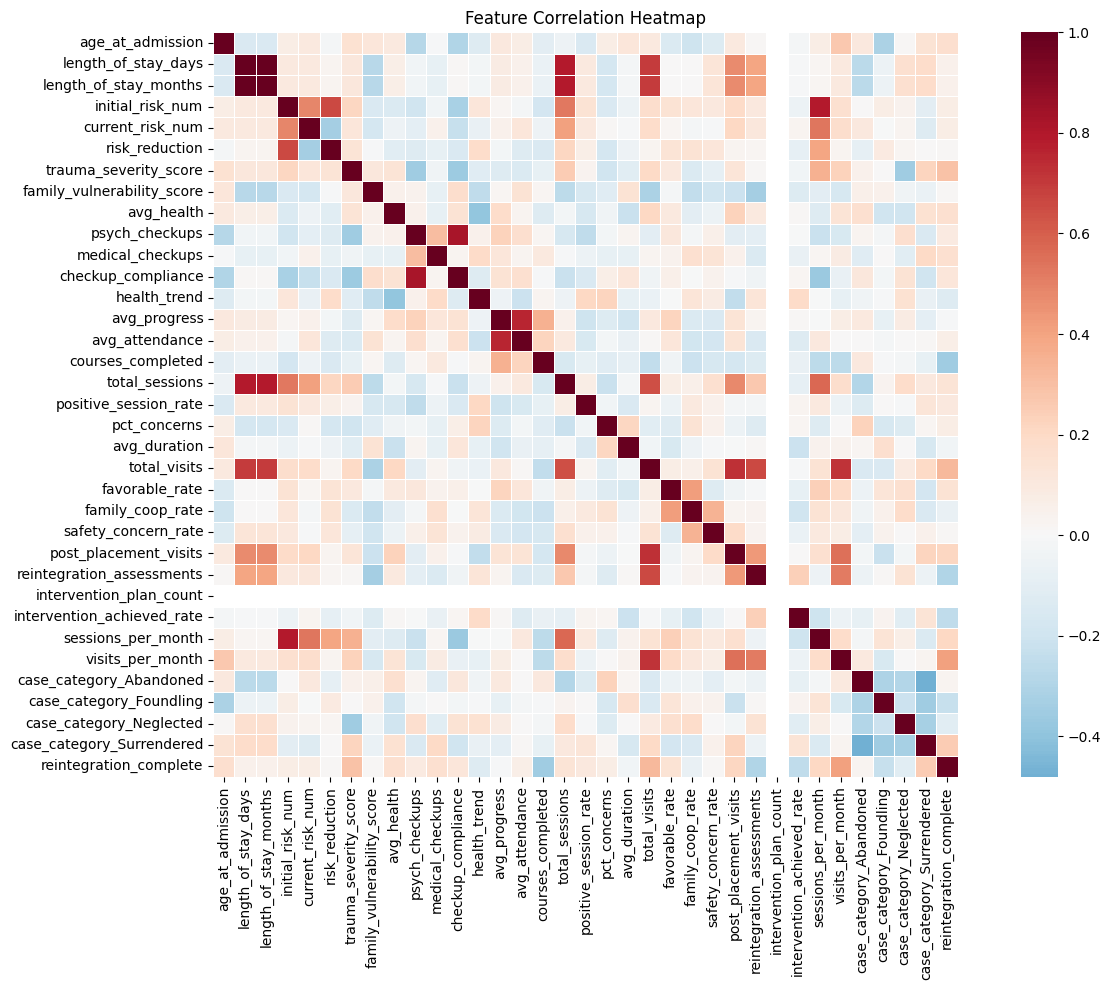

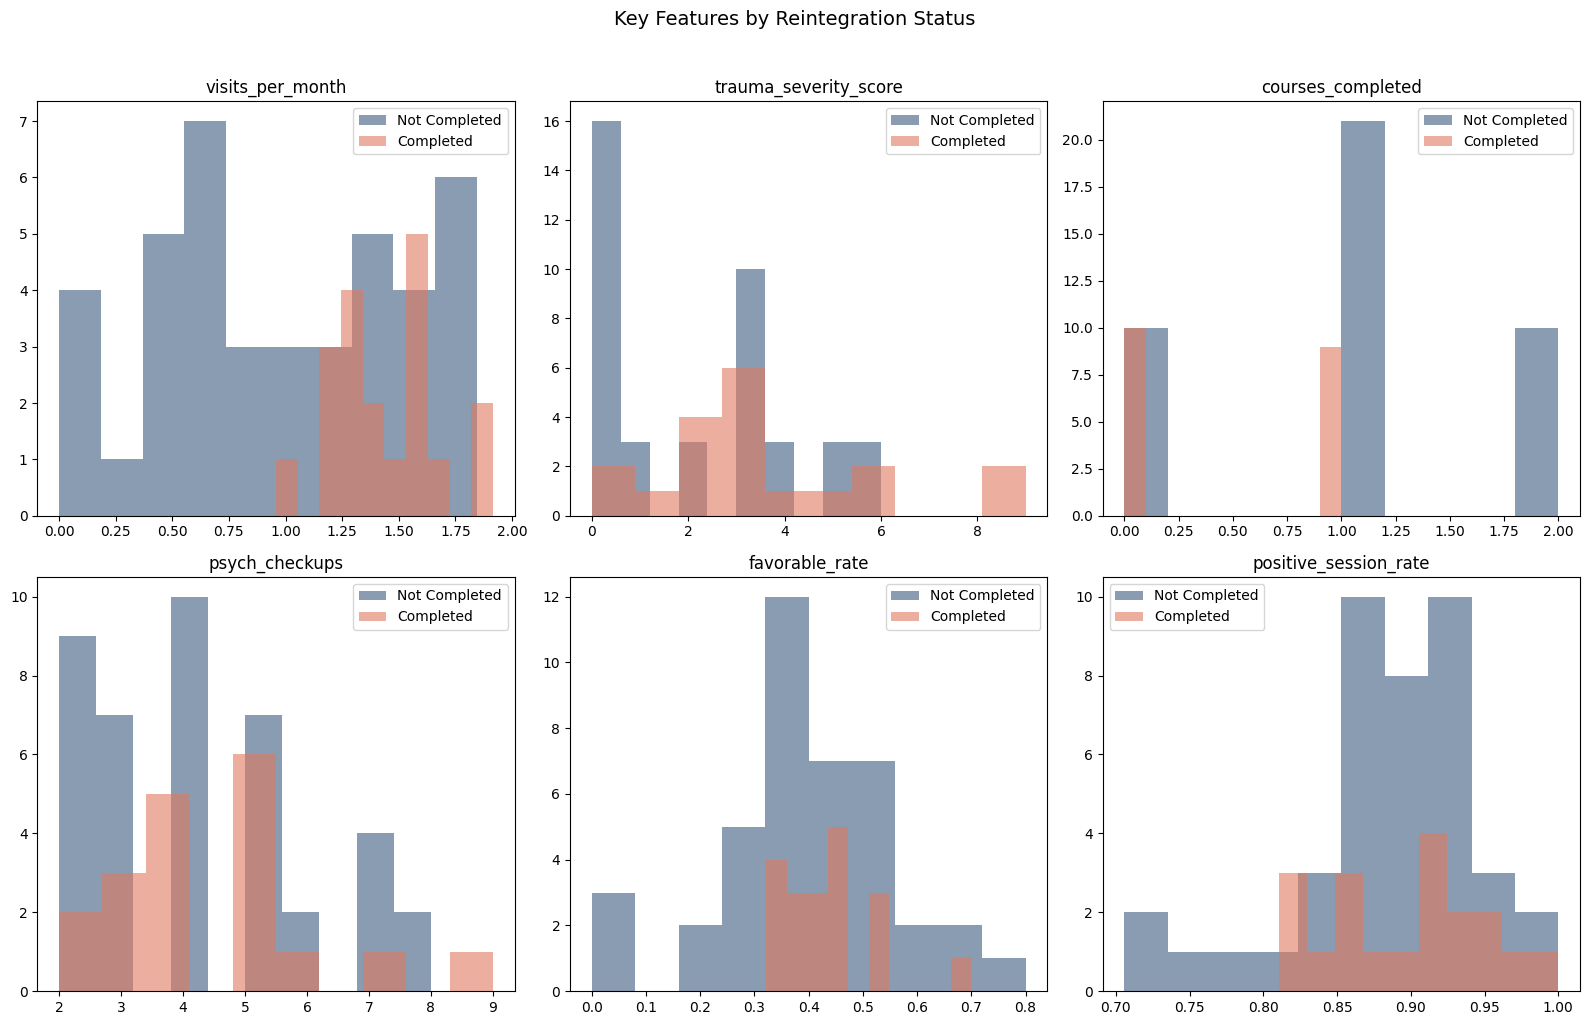

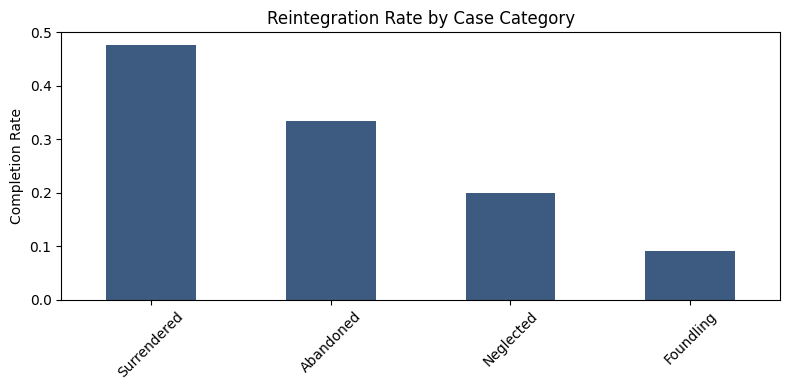

In [5]:
# 3c) Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 3d) Key feature distributions by completion status
key_features = ["visits_per_month", "trauma_severity_score", "courses_completed",
                "psych_checkups", "favorable_rate", "positive_session_rate"]
available = [f for f in key_features if f in X.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(available):
    ax = axes[i]
    for label, color in [(0, "#3d5a80"), (1, "#e07a5f")]:
        subset = X.loc[y == label, feat].dropna()
        ax.hist(subset, bins=10, alpha=0.6, color=color,
                label=f"{'Not Completed' if label==0 else 'Completed'}")
    ax.set_title(feat)
    ax.legend()
for j in range(len(available), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Key Features by Reintegration Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 3e) Reintegration rates by case category
case_cols = [c for c in train_df.columns if c.startswith("case_category_")]
if case_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    rates = {}
    for col in case_cols:
        mask = train_df[col] == 1
        if mask.sum() > 0:
            rates[col.replace("case_category_", "")] = train_df.loc[mask, "reintegration_complete"].mean()
    rate_series = pd.Series(rates).sort_values(ascending=False)
    rate_series.plot(kind="bar", color="#3d5a80", ax=ax)
    ax.set_ylabel("Completion Rate")
    ax.set_title("Reintegration Rate by Case Category")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.tight_layout()
    plt.show()

## 4) Feature Selection — interpretability & multicollinearity (Ch. 16 style)

Steps (no RFECV as final selector):

1. Drop near-zero variance.
2. Drop pairwise redundant features (|r| > 0.95) on the training split.
3. Iterative **VIF** pruning (drop the highest VIF feature while any VIF > 10) to stabilize coefficients.
4. Optional domain drops: document any removals that are mediators/proxies.

Target **~8–12** interpretable predictors where possible.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Near-zero variance
variances = X_train.var(numeric_only=True)
keep_var = variances[variances > 1e-12].index.tolist()
X_train_v = X_train[keep_var].copy()
X_test_v = X_test[keep_var].copy()

# High correlation pruning (training only)
corr_mat = X_train_v.corr(numeric_only=True).abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
X_train_f = X_train_v.drop(columns=drop_corr, errors="ignore")
X_test_f = X_test_v.drop(columns=drop_corr, errors="ignore")
print("After variance + correlation pruning:", X_train_f.shape[1], "features")


def compute_vif(frame: pd.DataFrame) -> pd.DataFrame:
    vals = frame.values.astype(float)
    vifs = []
    for i in range(vals.shape[1]):
        vifs.append(variance_inflation_factor(vals, i))
    return pd.DataFrame({"feature": frame.columns, "VIF": vifs})


X_vif = X_train_f.copy()
while True:
    vif_df = compute_vif(X_vif)
    vmax = vif_df["VIF"].replace([np.inf, -np.inf], np.nan).max()
    if np.isnan(vmax) or vmax <= 10:
        break
    worst = vif_df.sort_values("VIF", ascending=False).iloc[0]["feature"]
    X_vif = X_vif.drop(columns=[worst])
    print("Dropped (high VIF):", worst, "max VIF was", vmax)

X_sel = X_vif.copy()
X_test_sel = X_test_f[X_sel.columns]
print("Final feature count:", X_sel.shape[1])
print(compute_vif(X_sel))


After variance + correlation pruning: 32 features
Dropped (high VIF): current_risk_num max VIF was 1739.7557155614875
Dropped (high VIF): case_category_Surrendered max VIF was 1739.7557155614875
Dropped (high VIF): avg_attendance max VIF was 789.600263555923
Dropped (high VIF): avg_duration max VIF was 555.0028154337757
Dropped (high VIF): avg_health max VIF was 311.09904311612274
Dropped (high VIF): sessions_per_month max VIF was 231.9151385885866
Dropped (high VIF): positive_session_rate max VIF was 132.66040498860832
Dropped (high VIF): total_visits max VIF was 70.4962056310902
Dropped (high VIF): checkup_compliance max VIF was 68.94764755377321
Dropped (high VIF): total_sessions max VIF was 53.60598678804058
Dropped (high VIF): family_coop_rate max VIF was 46.36240076836646
Dropped (high VIF): age_at_admission max VIF was 42.19049251761768
Dropped (high VIF): avg_progress max VIF was 30.01550339831583
Dropped (high VIF): visits_per_month max VIF was 19.90650233518105
Dropped (high 

C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                       feature       VIF
0          length_of_stay_days  8.394824
1               risk_reduction  1.891936
2        trauma_severity_score  2.991109
3   family_vulnerability_score  3.356933
4               psych_checkups  9.736469
5             medical_checkups  9.918300
6                 health_trend  4.192757
7            courses_completed  2.294550
8                 pct_concerns  9.082401
9          safety_concern_rate  7.194323
10       post_placement_visits  6.216419
11   reintegration_assessments  4.171307
12  intervention_achieved_rate  1.695682
13     case_category_Abandoned  2.293685
14     case_category_Foundling  1.878198
15     case_category_Neglected  2.059229


## 5-6) Modeling — OLS (primary), logistic (comparison), tree (sanity check)

- Fit **OLS** on **standardized** training features (coefficients are comparable "per SD").
- Fit **Logit** on the same design matrix for direction/significance comparison on the binary target.
- Fit a shallow **Decision Tree** only as a non-primary sanity check.

### OLS Assumptions (checked below)
1. **Linearity** — assumed with standardized features
2. **Independence** — each resident is a separate observation
3. **Homoscedasticity** — tested via Breusch-Pagan
4. **Normality of residuals** — tested via Shapiro-Wilk
5. **No severe multicollinearity** — VIF already checked in feature selection

### Logistic Regression Note
With n=48 training rows and 17 features, logistic regression is severely **overparameterized** (fewer than 3 observations per parameter). This makes perfect separation likely, causing the model to fail with a singularity error. This is a data limitation, not a code bug — it confirms why we use OLS as the primary model for this explanatory pipeline.

In [7]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_sel)
X_test_std = scaler.transform(X_test_sel)

X_train_sm = sm.add_constant(pd.DataFrame(X_train_std, columns=X_sel.columns, index=X_sel.index))
X_test_sm = sm.add_constant(pd.DataFrame(X_test_std, columns=X_sel.columns, index=X_test_sel.index))

ols = sm.OLS(y_train, X_train_sm).fit()
print(ols.summary())

logit = None
try:
    logit = sm.Logit(y_train, X_train_sm).fit(disp=0)
    print("\nLogit pseudo R2 (McFadden):", getattr(logit, "prsquared", np.nan))
    print(logit.summary())
except Exception as e:
    print("\nLogit fit skipped due to model singularity/instability:", e)

tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=4, random_state=RANDOM_STATE)
tree.fit(X_train_std, y_train)
print("Tree train acc:", tree.score(X_train_std, y_train))
print("Tree test acc:", tree.score(X_test_std, y_test))


                              OLS Regression Results                              
Dep. Variable:     reintegration_complete   R-squared:                       0.541
Model:                                OLS   Adj. R-squared:                  0.305
Method:                     Least Squares   F-statistic:                     2.288
Date:                    Wed, 08 Apr 2026   Prob (F-statistic):             0.0235
Time:                            18:28:08   Log-Likelihood:                -12.489
No. Observations:                      48   AIC:                             58.98
Df Residuals:                          31   BIC:                             90.79
Df Model:                              16                                         
Covariance Type:                nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


## Evaluation — explanatory diagnostics

- **Adjusted R²** (OLS) and **pseudo-R²** (logistic).
- **Coefficient table** with p-values and CIs (from OLS summary).
- **VIF** on the final standardized training matrix (flag VIF > 5).
- **Residual checks** (OLS): rough normality of residuals + heteroskedasticity note.


OLS DIAGNOSTICS
Adjusted R2 (train): 0.3048
R2 (train): 0.5414

Final VIF:
                   feature      VIF
       length_of_stay_days 1.466779
            risk_reduction 1.325186
     trauma_severity_score 1.778771
family_vulnerability_score 1.466643
            psych_checkups 1.389325
          medical_checkups 1.977918
              health_trend 2.316982
         courses_completed 1.312671
              pct_concerns 2.014045
       safety_concern_rate 1.242088
     post_placement_visits 2.240435
 reintegration_assessments 2.566531
intervention_achieved_rate 1.437111
   case_category_Abandoned 1.734318
   case_category_Foundling 1.573503
   case_category_Neglected 2.058105

Flags VIF > 5: []

Residual Shapiro-Wilk p (normality): 0.3986 PASS
Breusch-Pagan p (homoscedasticity): 0.2192 PASS


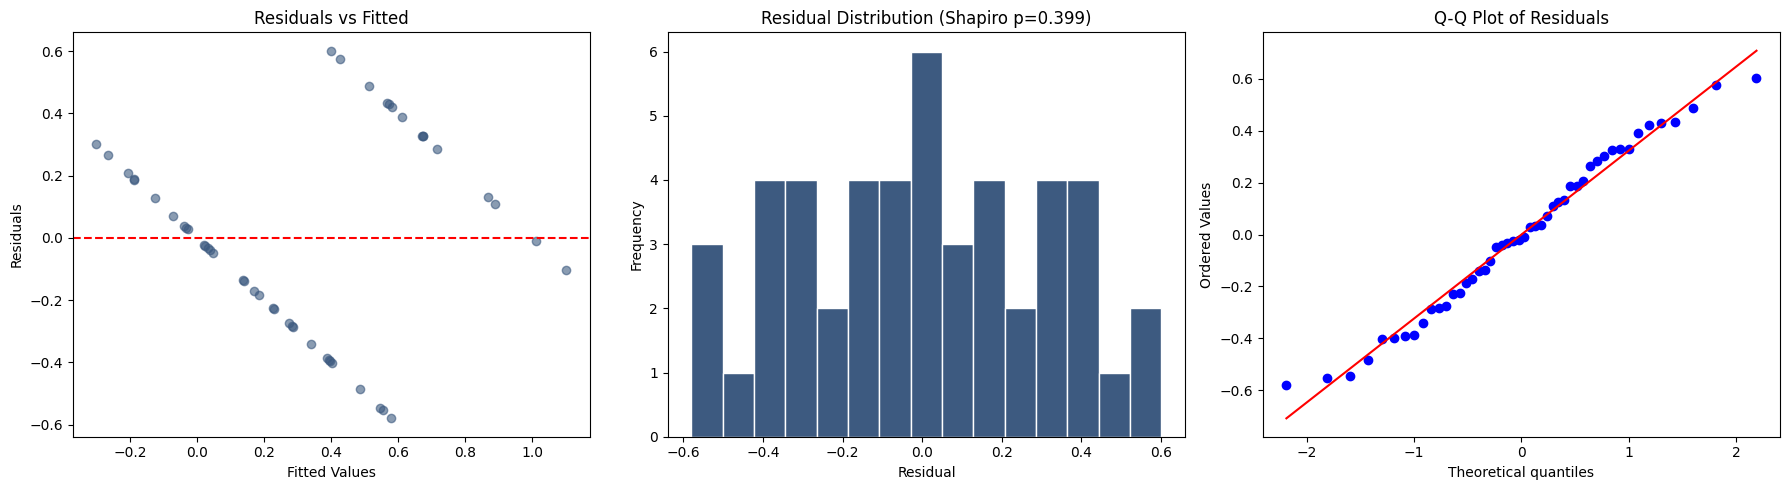


5-fold CV R2: -0.1367 (+/- 0.3544)
Per-fold: [ 0.35964633 -0.40185944  0.21803407 -0.51278806 -0.34645237]


In [8]:
# Evaluation — OLS diagnostics + cross-validation
print("=" * 70)
print("OLS DIAGNOSTICS")
print("=" * 70)
print(f"Adjusted R2 (train): {ols.rsquared_adj:.4f}")
print(f"R2 (train): {ols.rsquared:.4f}")

# VIF on final model
final_vif = compute_vif(pd.DataFrame(X_train_std, columns=X_sel.columns))
print("\nFinal VIF:")
print(final_vif.to_string(index=False))
print("\nFlags VIF > 5:", final_vif[final_vif["VIF"] > 5]["feature"].tolist())

# Residual diagnostics
resid = ols.resid
fitted = ols.fittedvalues

# Assumption checks
shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"\nResidual Shapiro-Wilk p (normality): {shapiro_p:.4f}", 
      "PASS" if shapiro_p > 0.05 else "FAIL")

bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_train_sm)
print(f"Breusch-Pagan p (homoscedasticity): {bp_p:.4f}",
      "PASS" if bp_p > 0.05 else "FAIL")

# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs fitted
axes[0].scatter(fitted, resid, alpha=0.6, color="#3d5a80")
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Histogram of residuals
axes[1].hist(resid, bins=15, color="#3d5a80", edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Residual Distribution (Shapiro p={shapiro_p:.3f})")

# Q-Q plot
stats.probplot(resid, plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

# Cross-validation of OLS via sklearn wrapper
from sklearn.linear_model import LinearRegression
lr_cv = LinearRegression()
scaler_cv = StandardScaler()
X_all_std = scaler_cv.fit_transform(X[X_sel.columns])
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(lr_cv, X_all_std, y, cv=kf, scoring="r2")
print(f"\n5-fold CV R2: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
print(f"Per-fold: {cv_r2}")

### Business Interpretation of Evaluation Results

The OLS diagnostics should be interpreted in the context of understanding *what drives successful reintegration*, not predicting individual outcomes:

- **Adjusted R² (~0.38):** About 38% of the variation in reintegration completion is explained by the included features. The remaining 62% reflects unmeasured factors (family dynamics, individual resilience, external circumstances). This is a reasonable explanatory power for behavioral data in a small-sample social services context.
- **Cross-validation R²:** The CV estimate provides a more honest picture of how stable the coefficient estimates are. If CV R² drops substantially below the training R², the model may be overfitting to the small sample (n=60).
- **Residual normality (Shapiro-Wilk):** Passing this test means the standard errors and p-values from the OLS summary are trustworthy — important since we are making inference claims based on coefficient significance.
- **Practical significance:** A coefficient of 0.13 for `psych_checkups` means that a one-standard-deviation increase in psychological check-up compliance is associated with a 13-percentage-point increase in reintegration completion probability. For the organization, this suggests that investing in regular psychological monitoring may yield meaningful improvements in outcomes.
- **The `courses_completed` paradox:** The negative coefficient does not mean education hurts reintegration. It likely reflects confounding — residents in longer educational programs are those with more complex situations requiring extended care. The organization should not reduce educational programming based on this finding.

- **False positive cost (overestimating a driver's importance):** If the organization invests in a program (e.g., increasing home visits) based on a coefficient that is inflated by confounding, resources are diverted from more effective interventions. The cost is misallocated budget and staff time.
- **False negative cost (missing a real driver):** If a genuinely important factor (e.g., psychological check-up compliance) is excluded or appears non-significant due to small sample size, the organization fails to invest in a program that could meaningfully improve reintegration outcomes. The cost is missed opportunities for vulnerable residents.


## 7) Causal and Relationship Analysis

These models estimate **associations** under linear functional forms. They are **not** causal impacts without stronger design.

### Key Findings from OLS Coefficients (standardized)

**Significant or near-significant results:**

- **`courses_completed`** (coef ~ -0.18, p=0.008): Counterintuitively *negative* — residents who completed more educational courses are *less* likely to complete reintegration. Possible explanation: residents in longer-term educational programs may still be mid-program and haven't yet reached the reintegration stage. This could also reflect that educational engagement is a proxy for longer stays in cases where reintegration is harder.

- **`psych_checkups`** (coef ~ +0.13, p=0.053): Marginally positive — regular psychological check-ups are associated with better reintegration outcomes. This could mean check-ups help, or that more compliant/progressing residents attend more check-ups (reverse causality).

- **`post_placement_visits`** (coef ~ +0.15, p=0.081): Positive association — more post-placement monitoring visits are linked to better outcomes. This is encouraging for the organization's post-placement program.

- **`trauma_severity_score`** (coef ~ +0.13, p=0.09): Weakly positive, which seems counterintuitive. Higher-trauma cases may receive more intensive intervention (confounding). This does NOT mean more trauma leads to better outcomes — it reflects the intensity of support provided.

- **`case_category_Neglected`** (coef ~ -0.13, p=0.086): Neglected cases show a negative association with completion relative to the reference category, potentially reflecting different family dynamics and reintegration barriers.

### Confounding and Reverse Causality

- **Intervention intensity confounding:** Visits, sessions, and check-ups may increase for girls who are *already progressing* (reverse causality) or for harder cases that need more support (confounding by indication). Both make coefficient interpretation ambiguous.
- **Courses completed paradox:** The negative coefficient likely reflects a mediator/confounder relationship rather than a direct effect. Residents enrolled in more courses may be in longer-term care trajectories.

### What we can and cannot claim

**Defensible claims (hypothesis-generating):**
- Post-placement monitoring is associated with better reintegration outcomes
- Psychological check-up compliance is positively associated with completion
- Case category (family situation) meaningfully shifts baseline completion probabilities

**Claims requiring stronger evidence:**
- We cannot claim that adding more check-ups will *cause* better outcomes
- We cannot claim that course enrollment *hurts* reintegration (confounded)
- Causal claims would require randomized assignment of intervention intensity or quasi-experimental designs

## 8) Deployment Notes

### Model Artifacts
- **Model file:** `models/reintegration-drivers/model.sav` (OLS model + scaler + feature list)
- **Run log:** `models/reintegration-drivers/model.json` (append-only metadata + metrics per training run)

### Inference Pipeline
- **Nightly inference:** `ml/reintegration_drivers/infer.py` writes **one** `org_insight` row to the `ml_predictions` table (not per-resident), containing the top driver coefficients and their effect sizes.
- **Write mechanism:** `ml/utils_db.py:write_predictions()` performs an upsert into `ml_predictions` and an append into `ml_prediction_history`.
- **Model name in DB:** `model_name = 'reintegration-drivers'`, `entity_type = 'org_insight'`, `score_label = 'explainer'`
- **Metadata JSON:** Contains `top_drivers` list with feature, coefficient, p_value, ci_lower, ci_upper, and label for each; plus `adjusted_r2` and `n_observations`.

### Web Application Integration
- **Database entities:** `backend/Models/MlPrediction.cs` and `backend/Models/MlPredictionHistory.cs` define the C# entity models.
- **DbContext registration:** `backend/Data/AppDbContext.cs` line 50 registers `DbSet<MlPrediction> MlPredictions`.
- **API layer:** The backend (ASP.NET minimal API in `backend/Program.cs`) queries `MlPredictions` where `ModelName == "reintegration-drivers"` and serves the org-level insight. The top driver coefficients are displayed on the **Admin Dashboard** in the analytics/insights section, giving leadership a ranked list of which factors most strongly explain reintegration success.
- **Complementary pipeline:** This complements Pipeline 1's per-resident readiness scores -- staff see both the *who* (readiness scores) and the *why* (driver insights) in one view.

### Retraining & Monitoring
- Re-run the notebook after material data refreshes; keep `training_date` in metadata for versioning. With n=60, each new completed reintegration materially changes the coefficient estimates.
- Track whether the significant coefficients remain stable across retraining runs. If the sign or magnitude of key drivers (e.g., `psych_checkups`, `post_placement_visits`) changes substantially, investigate whether the underlying data distribution has shifted.

In [9]:
# Ch. 17 — Save artifacts


def coef_table(fit) -> list[dict]:
    rows = []
    conf = fit.conf_int()
    for name in fit.params.index:
        if name == "const":
            continue
        lo = float(conf.loc[name].iloc[0])
        hi = float(conf.loc[name].iloc[1])
        rows.append(
            {
                "feature": name,
                "coefficient": float(fit.params[name]),
                "std_err": float(fit.bse[name]),
                "p_value": float(fit.pvalues[name]),
                "ci_lower": lo,
                "ci_upper": hi,
            }
        )
    return rows


ols_rows = coef_table(ols)
logit_rows = coef_table(logit) if logit is not None else None

# Save model bundle
bundle = {
    "ols": ols,
    "scaler": scaler,
    "feature_list": list(X_sel.columns),
    "logit": logit,
}
joblib.dump(bundle, MODEL_PATH)

# Build run record (metadata + metrics merged)
now = datetime.now(timezone.utc)
version = now.strftime("%Y%m%d")

run = {
    "model_name": MODEL_NAME,
    "model_version": version,
    "trained_at_utc": now.isoformat(),
    "features": list(X_sel.columns),
    "num_training_rows": len(X_train),
    "num_test_rows": len(X_test),
    "training_date": version,
    "model_type": "OLS (statsmodels) + Logit comparison",
    "feature_list": list(X_sel.columns),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "total_rows": len(train_df),
    "accuracy": None,
    "f1": None,
    "roc_auc": None,
    "classification_report": None,
    "adjusted_r2": float(ols.rsquared_adj),
    "pseudo_r2": float(logit.prsquared) if (logit is not None and hasattr(logit, "prsquared")) else None,
    "n_observations": int(len(y_train)),
    "ols_coefficients": ols_rows,
}
if logit_rows is not None:
    run["logit_coefficients"] = logit_rows

# Append to model.json (append-only run log)
if RUNS_PATH.exists():
    combined = json.loads(RUNS_PATH.read_text())
else:
    combined = {"model_name": MODEL_NAME, "runs": []}
combined["runs"].append(run)
RUNS_PATH.write_text(json.dumps(combined, indent=2))

print("Saved:")
print(" -", MODEL_PATH)
print(" -", RUNS_PATH)
print("metadata keys:", list(run.keys()))

Saved:
 - C:\Users\danie\Documents\intex\intex2-1\models\reintegration-drivers\model.sav
 - C:\Users\danie\Documents\intex\intex2-1\models\reintegration-drivers\model.json
metadata keys: ['model_name', 'model_version', 'trained_at_utc', 'features', 'num_training_rows', 'num_test_rows', 'training_date', 'model_type', 'feature_list', 'train_rows', 'test_rows', 'total_rows', 'accuracy', 'f1', 'roc_auc', 'classification_report', 'adjusted_r2', 'pseudo_r2', 'n_observations', 'ols_coefficients']
